# SECOM Big-Data Lane — Apache Pig + DuckDB

This demo reshapes SECOM into a long sensor-event stream and runs the same ingest + aggregation two ways: **Apache Pig** (local mode, JVM) and **DuckDB** (an in-process, **zero-Java** SQL engine that runs on a laptop).

> **Run the Pig section in Google Colab** (needs Java). **DuckDB needs no Java** and runs anywhere. Every cell degrades gracefully.

## Where this fits

- **Analysis & modelling** -> `secom_yield_analysis.ipynb` (pandas / scikit-learn; data fits in RAM).
- **This notebook** -> the **data-engineering** path: the same per-sensor + pass/fail aggregation expressed at warehouse scale.
- **Other variant** -> the sibling big-data notebook uses a different query engine for the same job.

The **big-data lane** (bottom) in the diagram below is what this notebook demonstrates.

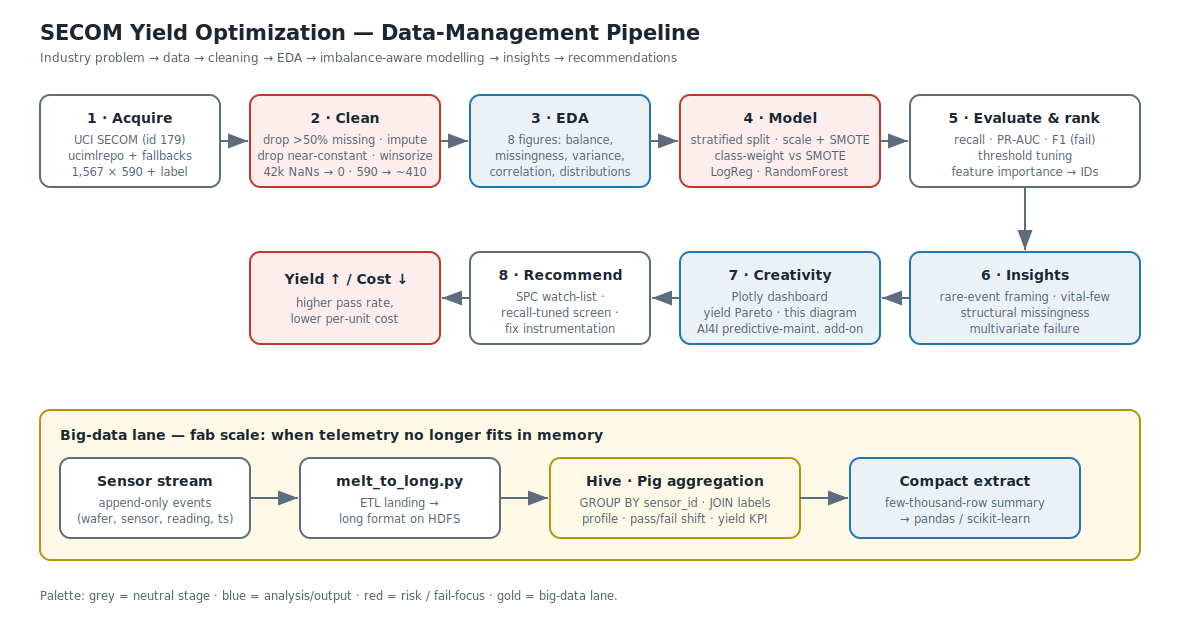

In [1]:
from IPython.display import display
# Pipeline overview (also saved at docs/pipeline_diagram.svg).
# Rendered as a raw image/svg+xml + html bundle so it shows in Colab,
# nbviewer and GitHub (no text/plain fallback).
PIPELINE_SVG = r'''<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 1180 640" font-family="Segoe UI, Helvetica, Arial, sans-serif">
  <defs>
    <marker id="arrow" markerWidth="10" markerHeight="10" refX="8" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L8,3 L0,6 Z" fill="#5D6D7E"/>
    </marker>
    <style>
      .stage  { fill:#ffffff; stroke:#5D6D7E; stroke-width:2; rx:10; }
      .accent { fill:#EAF2F8; stroke:#1F77B4; stroke-width:2; rx:10; }
      .risk   { fill:#FDEDEC; stroke:#C0392B; stroke-width:2; rx:10; }
      .big    { fill:#FEF9E7; stroke:#B7950B; stroke-width:2; rx:10; }
      .title  { font-size:21px; font-weight:700; fill:#1B2631; }
      .sub    { font-size:12px; fill:#566573; }
      .lbl    { font-size:14px; font-weight:700; fill:#1B2631; }
      .small  { font-size:11.5px; fill:#566573; }
      .tag    { font-size:11px; font-weight:700; fill:#1F77B4; }
      .flow   { stroke:#5D6D7E; stroke-width:2; fill:none; marker-end:url(#arrow); }
    </style>
  </defs>

  <text x="40" y="40" class="title">SECOM Yield Optimization — Data-Management Pipeline</text>
  <text x="40" y="62" class="sub">Industry problem → data → cleaning → EDA → imbalance-aware modelling → insights → recommendations</text>

  <!-- Row 1: main flow -->
  <!-- 1 Acquire -->
  <rect class="stage" x="40" y="95" width="180" height="92" rx="10"/>
  <text x="130" y="123" text-anchor="middle" class="lbl">1 · Acquire</text>
  <text x="130" y="144" text-anchor="middle" class="small">UCI SECOM (id 179)</text>
  <text x="130" y="160" text-anchor="middle" class="small">ucimlrepo + fallbacks</text>
  <text x="130" y="176" text-anchor="middle" class="small">1,567 × 590 + label</text>

  <!-- 2 Clean -->
  <rect class="risk" x="250" y="95" width="190" height="92" rx="10"/>
  <text x="345" y="123" text-anchor="middle" class="lbl">2 · Clean</text>
  <text x="345" y="144" text-anchor="middle" class="small">drop &gt;50% missing · impute</text>
  <text x="345" y="160" text-anchor="middle" class="small">drop near-constant · winsorize</text>
  <text x="345" y="176" text-anchor="middle" class="small">42k NaNs → 0 · 590 → ~410</text>

  <!-- 3 EDA -->
  <rect class="accent" x="470" y="95" width="180" height="92" rx="10"/>
  <text x="560" y="123" text-anchor="middle" class="lbl">3 · EDA</text>
  <text x="560" y="144" text-anchor="middle" class="small">8 figures: balance,</text>
  <text x="560" y="160" text-anchor="middle" class="small">missingness, variance,</text>
  <text x="560" y="176" text-anchor="middle" class="small">correlation, distributions</text>

  <!-- 4 Model -->
  <rect class="risk" x="680" y="95" width="200" height="92" rx="10"/>
  <text x="780" y="123" text-anchor="middle" class="lbl">4 · Model</text>
  <text x="780" y="144" text-anchor="middle" class="small">stratified split · scale + SMOTE</text>
  <text x="780" y="160" text-anchor="middle" class="small">class-weight vs SMOTE</text>
  <text x="780" y="176" text-anchor="middle" class="small">LogReg · RandomForest</text>

  <!-- 5 Evaluate -->
  <rect class="stage" x="910" y="95" width="230" height="92" rx="10"/>
  <text x="1025" y="123" text-anchor="middle" class="lbl">5 · Evaluate &amp; rank</text>
  <text x="1025" y="144" text-anchor="middle" class="small">recall · PR-AUC · F1 (fail)</text>
  <text x="1025" y="160" text-anchor="middle" class="small">threshold tuning</text>
  <text x="1025" y="176" text-anchor="middle" class="small">feature importance → IDs</text>

  <!-- arrows row1 -->
  <path class="flow" d="M220 141 L248 141"/>
  <path class="flow" d="M440 141 L468 141"/>
  <path class="flow" d="M650 141 L678 141"/>
  <path class="flow" d="M880 141 L908 141"/>

  <!-- down arrow to row2 -->
  <path class="flow" d="M1025 187 L1025 250"/>

  <!-- Row 2: outputs flowing right-to-left back to business -->
  <!-- 6 Insights -->
  <rect class="accent" x="910" y="252" width="230" height="92" rx="10"/>
  <text x="1025" y="280" text-anchor="middle" class="lbl">6 · Insights</text>
  <text x="1025" y="301" text-anchor="middle" class="small">rare-event framing · vital-few</text>
  <text x="1025" y="317" text-anchor="middle" class="small">structural missingness</text>
  <text x="1025" y="333" text-anchor="middle" class="small">multivariate failure</text>

  <!-- 7 Creativity -->
  <rect class="accent" x="680" y="252" width="200" height="92" rx="10"/>
  <text x="780" y="280" text-anchor="middle" class="lbl">7 · Creativity</text>
  <text x="780" y="301" text-anchor="middle" class="small">Plotly dashboard</text>
  <text x="780" y="317" text-anchor="middle" class="small">yield Pareto · this diagram</text>
  <text x="780" y="333" text-anchor="middle" class="small">AI4I predictive-maint. add-on</text>

  <!-- 8 Recommend -->
  <rect class="stage" x="470" y="252" width="180" height="92" rx="10"/>
  <text x="560" y="280" text-anchor="middle" class="lbl">8 · Recommend</text>
  <text x="560" y="301" text-anchor="middle" class="small">SPC watch-list ·</text>
  <text x="560" y="317" text-anchor="middle" class="small">recall-tuned screen ·</text>
  <text x="560" y="333" text-anchor="middle" class="small">fix instrumentation</text>

  <!-- Business outcome -->
  <rect class="risk" x="250" y="252" width="190" height="92" rx="10"/>
  <text x="345" y="284" text-anchor="middle" class="lbl">Yield ↑ / Cost ↓</text>
  <text x="345" y="307" text-anchor="middle" class="small">higher pass rate,</text>
  <text x="345" y="323" text-anchor="middle" class="small">lower per-unit cost</text>

  <!-- arrows row2 (leftward) -->
  <path class="flow" d="M910 298 L882 298"/>
  <path class="flow" d="M680 298 L652 298"/>
  <path class="flow" d="M470 298 L442 298"/>

  <!-- Big-data lane -->
  <rect class="big" x="40" y="410" width="1100" height="150" rx="12"/>
  <text x="60" y="440" class="lbl" fill="#7D6608">Big-data lane — fab scale: when telemetry no longer fits in memory</text>

  <rect class="stage" x="60" y="458" width="190" height="80" rx="10"/>
  <text x="155" y="486" text-anchor="middle" class="lbl">Sensor stream</text>
  <text x="155" y="507" text-anchor="middle" class="small">append-only events</text>
  <text x="155" y="523" text-anchor="middle" class="small">(wafer, sensor, reading, ts)</text>

  <rect class="stage" x="300" y="458" width="200" height="80" rx="10"/>
  <text x="400" y="486" text-anchor="middle" class="lbl">melt_to_long.py</text>
  <text x="400" y="507" text-anchor="middle" class="small">ETL landing →</text>
  <text x="400" y="523" text-anchor="middle" class="small">long format on HDFS</text>

  <rect class="big" x="550" y="458" width="250" height="80" rx="10"/>
  <text x="675" y="486" text-anchor="middle" class="lbl">Hive · Pig aggregation</text>
  <text x="675" y="507" text-anchor="middle" class="small">GROUP BY sensor_id · JOIN labels</text>
  <text x="675" y="523" text-anchor="middle" class="small">profile · pass/fail shift · yield KPI</text>

  <rect class="accent" x="850" y="458" width="230" height="80" rx="10"/>
  <text x="965" y="486" text-anchor="middle" class="lbl">Compact extract</text>
  <text x="965" y="507" text-anchor="middle" class="small">few-thousand-row summary</text>
  <text x="965" y="523" text-anchor="middle" class="small">→ pandas / scikit-learn</text>

  <path class="flow" d="M250 498 L298 498"/>
  <path class="flow" d="M500 498 L548 498"/>
  <path class="flow" d="M800 498 L848 498"/>

  <text x="40" y="600" class="small">Palette: grey = neutral stage · blue = analysis/output · red = risk / fail-focus · gold = big-data lane.</text>
</svg>
'''
display({'image/svg+xml': PIPELINE_SVG, 'text/html': PIPELINE_SVG}, raw=True)

## 0. Environment check + working directory

In [ ]:
import os, sys, shutil, platform

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False

WORK = '/content' if os.path.isdir('/content') else os.path.join(os.getcwd(), 'bigdata_work')
os.makedirs(WORK, exist_ok=True)
LONG_PATH = os.path.join(WORK, 'secom_sensor_long.tsv')
LABELS_PATH = os.path.join(WORK, 'secom_labels.tsv')
PIG_SCRIPT = os.path.join(WORK, 'secom_aggregate_local.pig')
PIG_OUT = os.path.join(WORK, 'pig_out')

print('Python :', platform.python_version(), '| OS:', platform.system())
print('In Colab:', IN_COLAB)
print('Java on PATH:', shutil.which('java'))
print('Work dir:', WORK)
if shutil.which('java') is None:
    print('\nNote: no Java found. Pig and Spark need a JVM; DuckDB (Section 4) does not.')

## 1. Build the long-format inputs

Load the UCI flat files, reshape to the long event stream `(wafer_id, sensor_id, reading)`, normalise the timestamp to ISO, and write two TSVs. This is the ETL 'landing' step.

In [ ]:
import pandas as pd
import numpy as np

base = 'https://archive.ics.uci.edu/ml/machine-learning-databases/secom/'
feat = pd.read_csv(base + 'secom.data', sep=r'\s+', header=None, na_values=['NaN'])
lab = pd.read_csv(base + 'secom_labels.data', sep=r'\s+', header=None, names=['label', 'date', 'clock'])

# Timestamp is DD/MM/YYYY HH:MM:SS in the raw file -> parse and re-emit as ISO
ts = pd.to_datetime(lab['date'] + ' ' + lab['clock'], dayfirst=True, errors='coerce')
event_ts = ts.dt.strftime('%Y-%m-%d %H:%M:%S').fillna('NA')

labels = pd.DataFrame({
    'wafer_id': range(len(lab)),
    'label_raw': lab['label'].astype(int),
    'fail': (lab['label'].astype(int) == 1).astype(int),
    'event_ts': event_ts,
})
labels.to_csv(LABELS_PATH, sep='\t', index=False, header=False)

feat.insert(0, 'wafer_id', range(len(feat)))
long = (feat.melt(id_vars='wafer_id', var_name='sensor_id', value_name='reading')
            .dropna(subset=['reading']))
long['sensor_id'] = long['sensor_id'].astype(int)
long.to_csv(LONG_PATH, sep='\t', index=False, header=False)

print('wafers:', len(labels), '| sensor events:', len(long))
print(long.head())
print(labels.head())

## 2. Apache Pig — local mode (real Pig Latin)

Installs OpenJDK 8 and Pig 0.17, writes the Pig script (mirror of `src/bigdata/secom_aggregate.pig`), and runs it. Never raises — if Pig will not run here, the next section still produces output.

In [ ]:
import os, subprocess, urllib.request, tarfile

PIG_DIR = os.path.join(WORK, 'pig-0.17.0')
PIG_TGZ = os.path.join(WORK, 'pig-0.17.0.tar.gz')
PIG_BIN = os.path.join(PIG_DIR, 'bin', 'pig')

if shutil.which('apt-get'):
    print('Installing OpenJDK 8 via apt (~30s)...')
    subprocess.run('apt-get -qq update', shell=True)
    subprocess.run('apt-get -qq install -y openjdk-8-jdk-headless', shell=True)
else:
    print('No apt-get here; will use whatever Java is on PATH.')
JAVA8 = '/usr/lib/jvm/java-8-openjdk-amd64'
print('Java 8 present:', os.path.isdir(JAVA8), '| any Java:', shutil.which('java'))

if not os.path.exists(PIG_BIN):
    urls = ['https://archive.apache.org/dist/pig/pig-0.17.0/pig-0.17.0.tar.gz',
            'https://downloads.apache.org/pig/pig-0.17.0/pig-0.17.0.tar.gz']
    got = False
    for u in urls:
        try:
            print('Downloading Pig from', u, '...')
            urllib.request.urlretrieve(u, PIG_TGZ)
            if os.path.exists(PIG_TGZ) and os.path.getsize(PIG_TGZ) > 50_000_000:
                got = True
                break
            print('  download too small/missing, trying next mirror')
        except Exception as e:
            print('  failed:', repr(e))
    if got:
        print('Extracting...')
        with tarfile.open(PIG_TGZ) as t:
            t.extractall(WORK)
    else:
        print('Could not download Pig -> skip to Section 3/4.')

print('Pig binary present:', os.path.exists(PIG_BIN))

In [ ]:
# Write the local-mode Pig script (mirror of src/bigdata/secom_aggregate.pig)
pig_body = r'''-- Local-mode mirror of src/bigdata/secom_aggregate.pig
-- Variance via E[x^2]-E[x]^2 so no external UDF (Pig core has no VAR builtin).
sensors = LOAD '__LONG__' USING PigStorage('\t') AS (wafer_id:int, sensor_id:int, reading:double);
labels  = LOAD '__LABELS__' USING PigStorage('\t') AS (wafer_id:int, label_raw:int, fail:int, event_ts:chararray);

clean_sensors = FILTER sensors BY reading IS NOT NULL;
squared = FOREACH clean_sensors GENERATE sensor_id, reading, (reading*reading) AS r2;
by_sensor = GROUP squared BY sensor_id;
sensor_prof = FOREACH by_sensor GENERATE group AS sensor_id, COUNT(squared) AS n_readings, AVG(squared.reading) AS mean_reading, (AVG(squared.r2)-AVG(squared.reading)*AVG(squared.reading)) AS variance_reading;
informative = FILTER sensor_prof BY variance_reading > 1e-9;

joined = JOIN clean_sensors BY wafer_id, labels BY wafer_id;
labelled = FOREACH joined GENERATE clean_sensors::sensor_id AS sensor_id, clean_sensors::reading AS reading, labels::fail AS fail;
by_sensor_class = GROUP labelled BY sensor_id;
passfail = FOREACH by_sensor_class { pass_rows = FILTER labelled BY fail==0; fail_rows = FILTER labelled BY fail==1; GENERATE group AS sensor_id, AVG(pass_rows.reading) AS mean_pass, AVG(fail_rows.reading) AS mean_fail; }
shift = FOREACH passfail GENERATE sensor_id, mean_pass, mean_fail, (mean_fail-mean_pass) AS mean_shift, ABS(mean_fail-mean_pass) AS abs_shift;
ranked = ORDER shift BY abs_shift DESC;
top15 = LIMIT ranked 15;

STORE informative INTO '__OUT__/sensor_profile' USING PigStorage('\t');
DUMP top15;
'''
pig_body = (pig_body.replace('__LONG__', LONG_PATH)
                    .replace('__LABELS__', LABELS_PATH)
                    .replace('__OUT__', PIG_OUT))
with open(PIG_SCRIPT, 'w') as f:
    f.write(pig_body)
print('Wrote Pig script ->', PIG_SCRIPT)

In [ ]:
import os, subprocess, shutil

if not os.path.exists(PIG_BIN):
    print('Pig not installed -> skip to Section 3/4.')
elif shutil.which('java') is None:
    print('No Java on PATH -> Pig cannot run.')
else:
    env = dict(os.environ)
    env['PIG_HOME'] = PIG_DIR
    if os.path.isdir(JAVA8):
        env['JAVA_HOME'] = JAVA8
    env['PIG_HEAPSIZE'] = '4096'
    print('JAVA_HOME =', env.get('JAVA_HOME', '(default)'))
    if os.path.isdir(PIG_OUT):
        shutil.rmtree(PIG_OUT)
    try:
        res = subprocess.run([PIG_BIN, '-x', 'local', '-f', PIG_SCRIPT],
                             capture_output=True, text=True, env=env, timeout=900)
        print('Pig return code:', res.returncode)
        print('=== STDOUT (DUMP of top-15 pass/fail signals) ===')
        print(res.stdout[-3500:] or '(no stdout)')
        print('=== STDERR (tail) ===')
        print(res.stderr[-1200:])
        if res.returncode != 0:
            print('\nPig did not finish cleanly. Sections 3-4 demonstrate the same aggregation.')
    except Exception as e:
        print('Pig run raised:', repr(e))

## 3. DuckDB — the zero-Java, laptop-scale engine

**DuckDB** is a modern in-process analytical (OLAP) SQL engine — 'SQLite for analytics'. `pip install duckdb` and run Hive-style SQL directly on the Section-1 DataFrames (or CSV/Parquet), columnar and vectorised. Same four queries as the Hive version, no cluster and no Java.

In [ ]:
!pip -q install duckdb
import duckdb

con = duckdb.connect()
con.register('secom_sensor_long', long)     # query the Section-1 DataFrames directly
con.register('secom_labels', labels)

print('--- Per-sensor profile (first 5) ---')
print(con.sql('SELECT sensor_id, COUNT(*) AS n_readings, ROUND(AVG(reading),4) AS mean_reading, ROUND(STDDEV_POP(reading),6) AS std_reading, MIN(reading) AS min_reading, MAX(reading) AS max_reading FROM secom_sensor_long GROUP BY sensor_id ORDER BY sensor_id LIMIT 5').df().to_string(index=False))

print('\n--- Missingness per sensor (worst 5; 1567 expected) ---')
print(con.sql('SELECT sensor_id, COUNT(*) AS n_readings, (1567-COUNT(*)) AS n_missing, ROUND((1567-COUNT(*))/1567.0,4) AS missing_frac FROM secom_sensor_long GROUP BY sensor_id ORDER BY missing_frac DESC LIMIT 5').df().to_string(index=False))

print('\n--- Top 15 pass/fail mean-shift signals (JOIN) ---')
print(con.sql('SELECT sensor_id, ROUND(mean_pass,4) AS mean_pass, ROUND(mean_fail,4) AS mean_fail, ROUND(mean_fail-mean_pass,4) AS mean_shift FROM (SELECT s.sensor_id AS sensor_id, AVG(CASE WHEN l.fail=0 THEN s.reading END) AS mean_pass, AVG(CASE WHEN l.fail=1 THEN s.reading END) AS mean_fail FROM secom_sensor_long s JOIN secom_labels l ON s.wafer_id=l.wafer_id GROUP BY s.sensor_id) t ORDER BY ABS(mean_fail-mean_pass) DESC LIMIT 15').df().to_string(index=False))

print('\n--- Daily fab yield KPI ---')
print(con.sql('SELECT SUBSTR(event_ts,1,10) AS run_date, COUNT(*) AS wafers, SUM(fail) AS fails, ROUND(1 - SUM(fail)*1.0/COUNT(*),4) AS yield_rate FROM secom_labels GROUP BY run_date ORDER BY run_date LIMIT 10').df().to_string(index=False))

## What this shows

**Pig** (procedural, JVM) and **DuckDB** (declarative SQL, no JVM) produce the same per-sensor profile and ranked pass/fail signals. DuckDB is the pragmatic modern middle ground: for when data is bigger than pandas likes but a Hadoop/Spark cluster is overkill — it runs identically here or on your own PC.

**Engine spectrum:** pandas (in-RAM ML) -> DuckDB (fast single-node SQL, zero infra) -> Hive/Spark (partitioned TB-scale) -> Pig (procedural ETL). Canonical Pig script: `src/bigdata/secom_aggregate.pig`. For the Hive/Spark variant, see `bigdata_demo_pig_hive.ipynb`.